# APS1: Classificador de Falhas em Máquinas Rotativas Acionadas por Motores Elétricos

Inteligência Artificial para Automação, Insper. Prof. Fábio Ferraz Júnior.

- Overview:

Máquinas rotativas industriais acionadas por motores elétricos estão sujeitas a falhas mecânicas que, se não detectadas a tempo, causam paradas não planejadas e prejuízos, e o objetivo deste projeto é aplicar Aprendizado de Máquina para classificar automaticamente a condição operacional da máquina em uma de cinco classes (Normal, Desacoplado, Sobrecarga, Desbalanceado ou Desalinhado) a partir de atributos elétricos e de vibração coletados de uma bancada eletromecânica, apoiando estratégias de manutenção preditiva.

- Medida de Desempenho:

Como o problema é de classificação multiclasse e as classes são balanceadas (verificado na exploração dos dados), a **acurácia** é a métrica principal. Nesse cenário, ela coincide com o recall macro (média do recall das cinco classes) e é a mais simples de interpretar. Recall, precisão e F1-score macro são acompanhados de forma complementar.

No contexto industrial, o erro mais caro é uma falha ser classificada como Normal (falso negativo), pois isso pode levar a uma parada não planejada, enquanto um alarme falso gera, no máximo, uma manutenção antecipada. Como as métricas macro não isolam esse erro, ele é monitorado diretamente na matriz de confusão, contando quantas falhas foram previstas como Normal.

Os hiperparâmetros são otimizados com **Optuna**, usando validação cruzada por blocos de tempo. Os modelos candidatos são comparados em uma validação temporal separada, com matriz de confusão e curva ROC one-vs-rest (AUC por classe), e o conjunto de teste é usado uma única vez, para medir o desempenho dos modelos já escolhidos. Em caso de desempenho próximo, é priorizado o modelo mais interpretável.

- Hipóteses:

**H1: Automação inteligente da detecção de falhas.** Os sinais elétricos e de vibração da bancada carregam informação suficiente para que um modelo de ML classifique as cinco condições operacionais com alto desempenho. Com isso, a identificação das falhas deixa de depender da inspeção manual do engenheiro e passa a ser feita automaticamente, apoiando a manutenção preditiva.

**H2: Redução do número de sensores.** A instrumentação atual usa cinco sinais (três grandezas elétricas e dois acelerômetros), cada um com transdutor e hardware de aquisição próprios. Supõe-se que um subconjunto desses sinais mantenha desempenho equivalente ao conjunto completo, o que reduziria custo, complexidade de instalação e volume de dados que o engenheiro precisa acompanhar.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/Dataset APS1_Sinais Eletricos e Vibracao_csv.xls")
print(f'O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.\n')
print(f'As colunas são: {df.columns}\n')
df.head(5)

O dataset possui 2505 linhas e 20 colunas.

As colunas são: Index(['tempo_s', 'tipo_setup', 'I_entrada_A', 'P_entrada_W', 'I_saida_A',
       'DesvPad_I_entrada_A', 'DesvPad _P_entrada_W', 'DesvPad _I_saida_A',
       'Amp_I_entrada_A', 'Amp_P_entrada_W', 'Amp_I_saida_A',
       'Kurtosis_I_entrada_A', 'Kurtosis_P_entrada_W', 'Kurtosis_I_saida_A',
       'Mag_S1_f1_dBrms', 'Mag_S1_f2_dBrms', 'Mag_S1_f3_dBrms',
       'Mag_S2_f1_dBrms', 'Mag_S2_f2_dBrms', 'Mag_S2_f3_dBrms'],
      dtype='str')



,tempo_s,tipo_setup,I_entrada_A,P_entrada_W,I_saida_A,DesvPad_I_entrada_A,DesvPad _P_entrada_W,DesvPad _I_saida_A,Amp_I_entrada_A,Amp_P_entrada_W,Amp_I_saida_A,Kurtosis_I_entrada_A,Kurtosis_P_entrada_W,Kurtosis_I_saida_A,Mag_S1_f1_dBrms,Mag_S1_f2_dBrms,Mag_S1_f3_dBrms,Mag_S2_f1_dBrms,Mag_S2_f2_dBrms,Mag_S2_f3_dBrms
0,0.00,0.0,0.44905,63.67320,1.43660,0.042740,21.869566,0.113479,0.175,91.738,0.406,12.474475,15.435837,4.223108,-50.647991,-63.189443,-47.864704,-59.629807,-73.010381,-49.583755
1,0.08,0.0,0.44610,69.40320,1.67860,0.048945,1.600020,0.854342,0.227,7.359,3.843,20.070610,13.335535,16.966677,-50.696943,-63.340003,-48.313132,-59.591150,-72.360239,-49.473893
2,0.16,0.0,0.45175,69.11385,1.39950,0.042337,5.220348,0.284000,0.207,24.185,1.395,19.087723,7.345771,11.032327,-47.724322,-62.837371,-48.384219,-55.194912,-63.127903,-48.083630
3,0.24,0.0,0.43510,68.85665,1.39705,0.063224,3.437546,0.219507,0.228,16.040,0.973,6.869051,19.849528,9.136137,-47.652608,-62.613368,-48.768793,-55.275822,-63.310116,-47.937933
4,0.32,0.0,0.45055,70.52860,1.43375,0.048497,1.240032,0.111967,0.222,4.394,0.425,20.205840,2.325535,2.818658,-47.019446,-61.314274,-49.016646,-54.665312,-60.825200,-47.886619


# Data Exploration

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2505 entries, 0 to 2504
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tempo_s               2505 non-null   float64
 1   tipo_setup            2505 non-null   float64
 2   I_entrada_A           2505 non-null   float64
 3   P_entrada_W           2505 non-null   float64
 4   I_saida_A             2505 non-null   float64
 5   DesvPad_I_entrada_A   2505 non-null   float64
 6   DesvPad _P_entrada_W  2505 non-null   float64
 7   DesvPad _I_saida_A    2505 non-null   float64
 8   Amp_I_entrada_A       2505 non-null   float64
 9   Amp_P_entrada_W       2505 non-null   float64
 10  Amp_I_saida_A         2505 non-null   float64
 11  Kurtosis_I_entrada_A  2505 non-null   float64
 12  Kurtosis_P_entrada_W  2505 non-null   float64
 13  Kurtosis_I_saida_A    2505 non-null   float64
 14  Mag_S1_f1_dBrms       2505 non-null   float64
 15  Mag_S1_f2_dBrms       2505 non-n

In [5]:
df.describe()

,tempo_s,tipo_setup,I_entrada_A,P_entrada_W,I_saida_A,DesvPad_I_entrada_A,DesvPad _P_entrada_W,DesvPad _I_saida_A,Amp_I_entrada_A,Amp_P_entrada_W,Amp_I_saida_A,Kurtosis_I_entrada_A,Kurtosis_P_entrada_W,Kurtosis_I_saida_A,Mag_S1_f1_dBrms,Mag_S1_f2_dBrms,Mag_S1_f3_dBrms,Mag_S2_f1_dBrms,Mag_S2_f2_dBrms,Mag_S2_f3_dBrms
count,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000
mean,20.000000,2.000000,0.467173,71.095485,1.510273,0.062549,10.030840,0.495564,0.280475,46.371912,2.225988,12.050777,14.937885,11.168255,-39.983011,-54.772230,-47.535366,-45.145129,-55.583079,-46.578764
std,11.572386,1.414496,0.037798,6.369966,0.138248,0.057536,11.105669,0.375317,0.269268,52.036291,1.767510,5.230828,6.931692,7.207961,4.949400,9.313107,5.857693,6.269441,9.072283,3.855181
min,0.000000,0.000000,0.261900,38.470250,0.810650,0.001372,0.543396,0.063909,0.005000,1.893000,0.244000,1.660392,1.325033,1.187931,-50.696943,-71.520216,-58.985078,-65.271484,-73.010381,-54.985263
25%,10.000000,1.000000,0.445700,67.307950,1.419950,0.041017,2.689081,0.154070,0.183000,12.789000,0.596000,7.971048,9.554414,4.030760,-43.902336,-59.541521,-52.053099,-50.245276,-63.067057,-49.493122
50%,20.000000,2.000000,0.456750,69.612150,1.479250,0.056569,8.407893,0.377251,0.244000,38.618000,1.745000,10.701860,16.355427,9.754281,-41.943547,-54.967319,-47.868026,-48.353184,-59.158229,-47.233461
75%,30.000000,3.000000,0.472450,73.029150,1.590750,0.070714,12.983316,0.879553,0.302000,58.301000,4.108000,15.927991,21.599938,18.540216,-34.647596,-50.619857,-41.947513,-37.978948,-49.267334,-42.830915
max,40.000000,4.000000,0.625950,96.651550,2.118200,0.860274,149.491667,2.007972,3.881000,672.213000,10.687000,22.979158,22.994930,22.794465,-31.993773,-37.605394,-36.684861,-35.173001,-37.765710,-38.495491


In [6]:
import matplotlib.pyplot as plt

contagem = df["tipo_setup"].value_counts().sort_index()
percentual = df["tipo_setup"].value_counts(normalize=True).sort_index() * 100

print(contagem)
print(percentual)

tipo_setup
0.0    501
1.0    501
2.0    501
3.0    501
4.0    501
Name: count, dtype: int64
tipo_setup
0.0    20.0
1.0    20.0
2.0    20.0
3.0    20.0
4.0    20.0
Name: proportion, dtype: float64


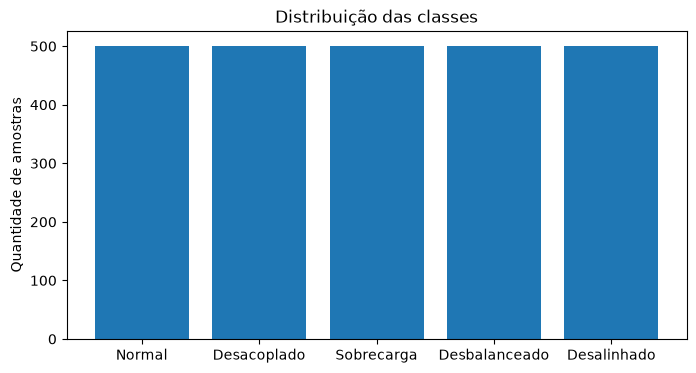

In [7]:
nomes_classes = ["Normal", "Desacoplado", "Sobrecarga", "Desbalanceado", "Desalinhado"]

plt.figure(figsize=(8, 4))
plt.bar(nomes_classes, contagem.values)
plt.title("Distribuição das classes")
plt.ylabel("Quantidade de amostras")
plt.show()

### Distribuição das variáveis

Histograma e boxplot de cada atributo, para identificar assimetrias, outliers e padrões multimodais.

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


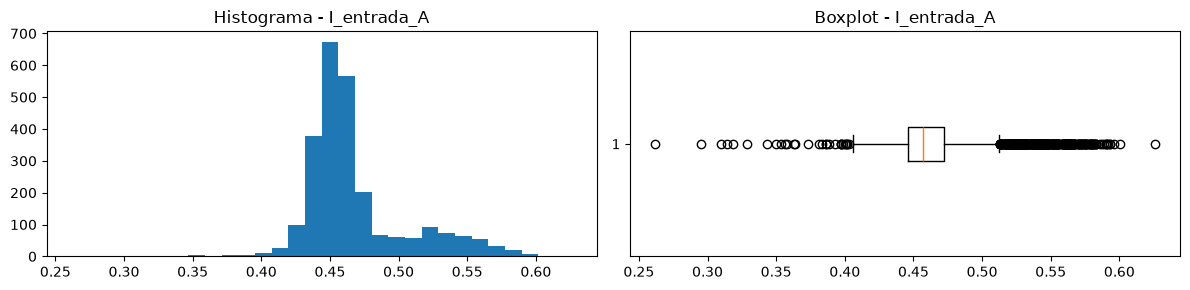

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


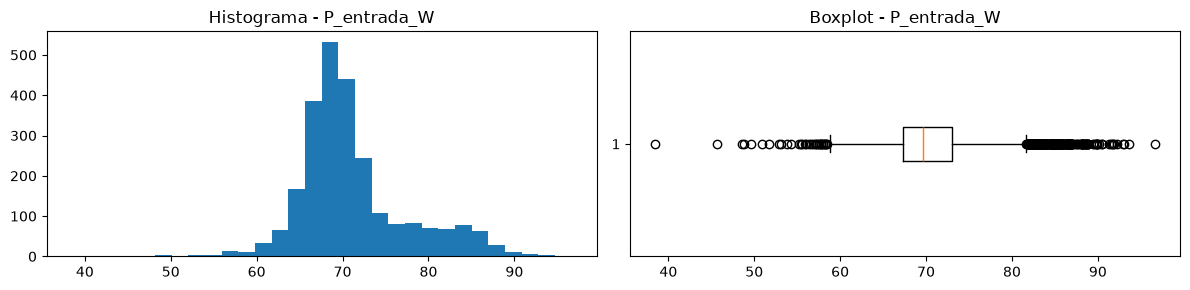

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


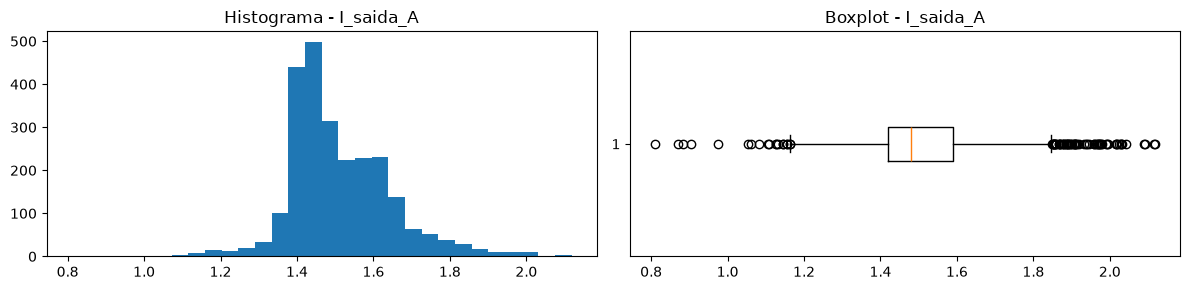

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


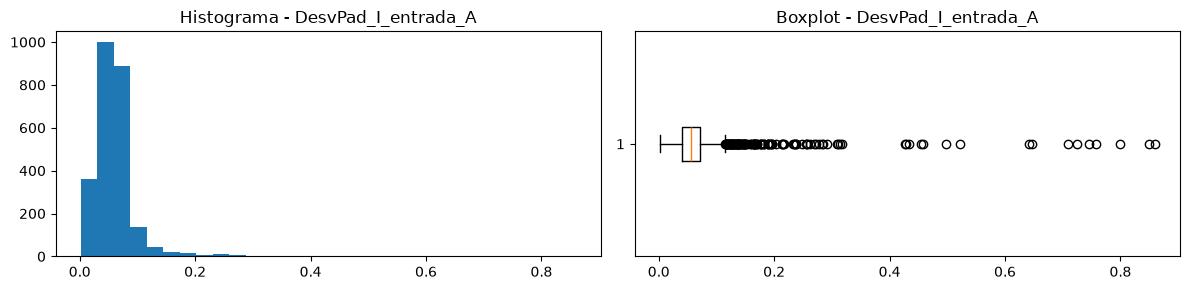

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


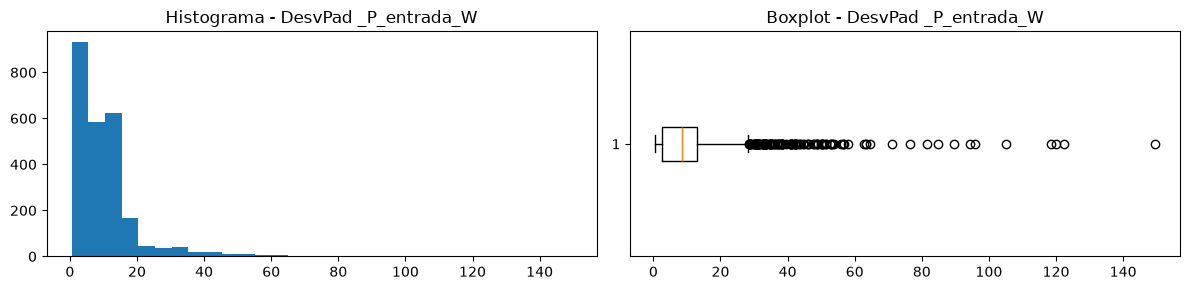

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


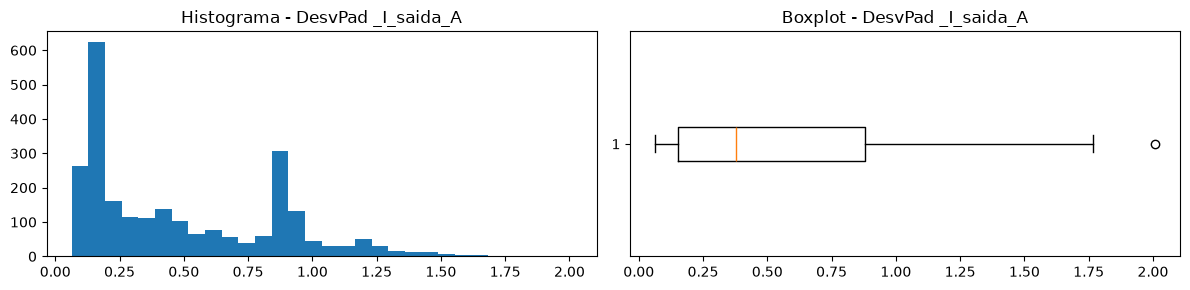

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


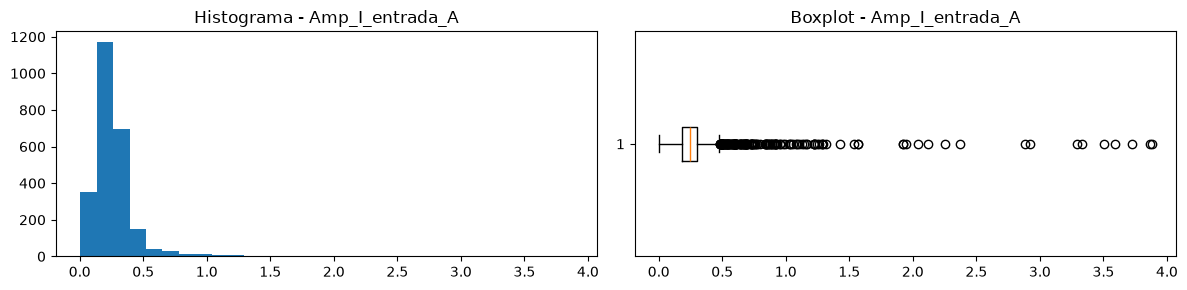

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


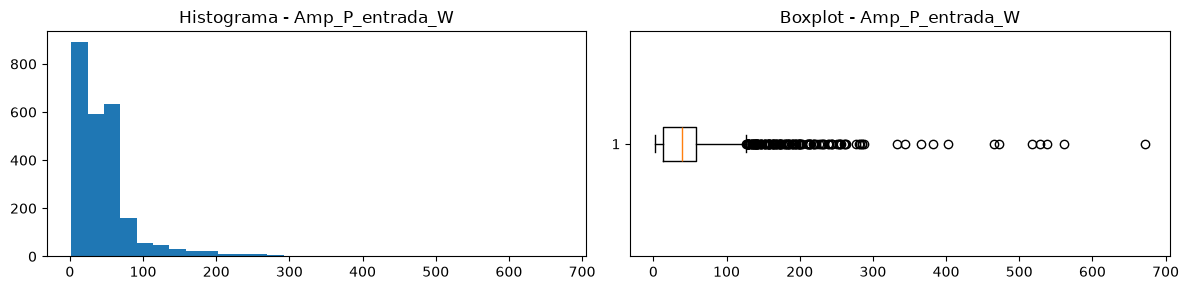

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


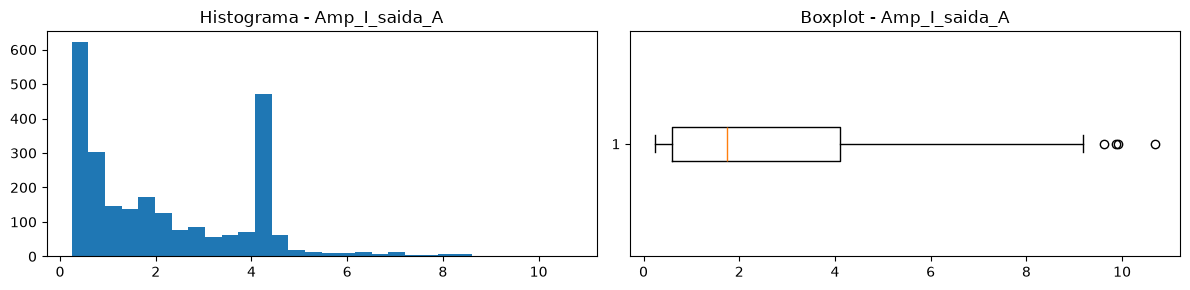

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


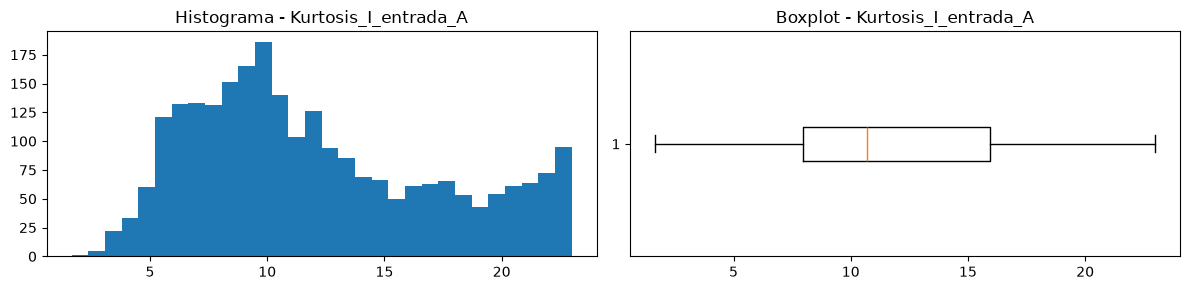

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


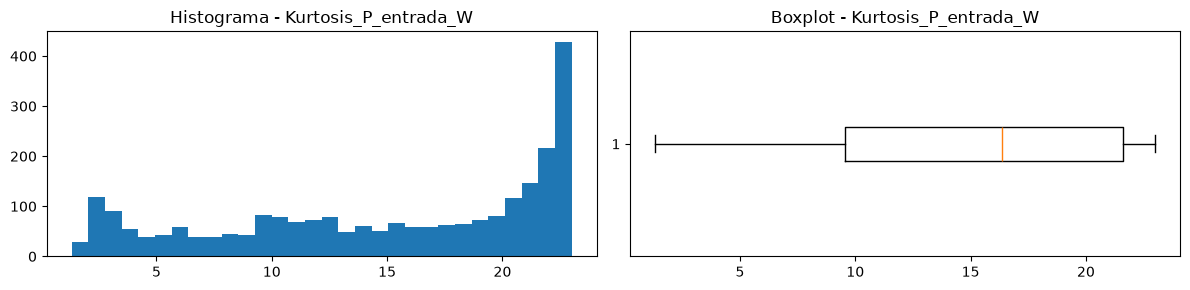

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


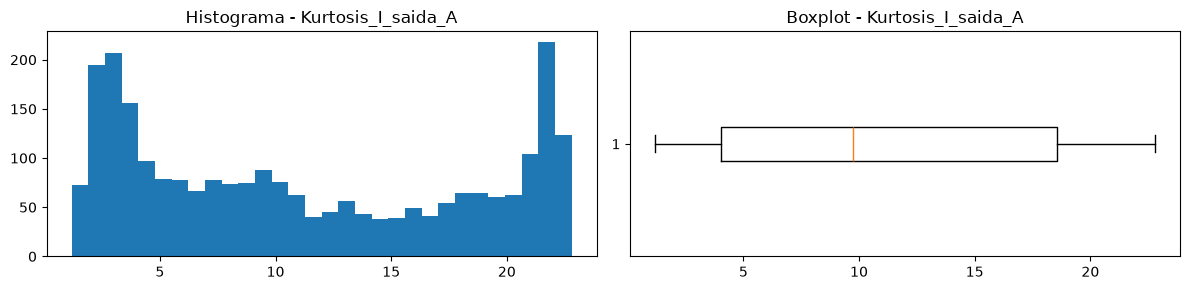

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


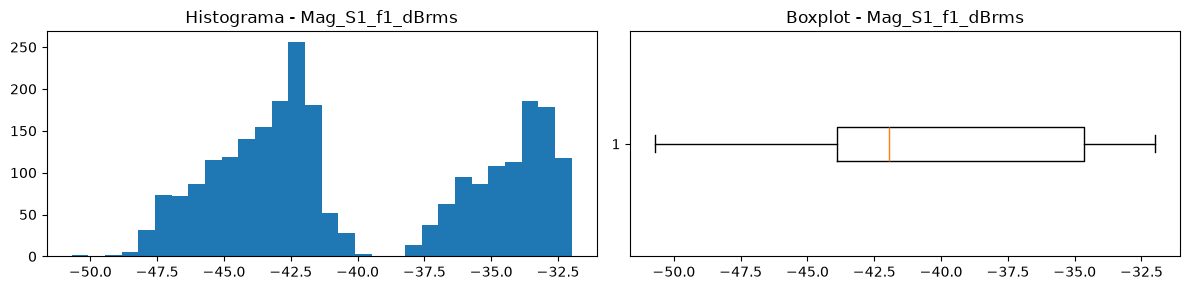

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


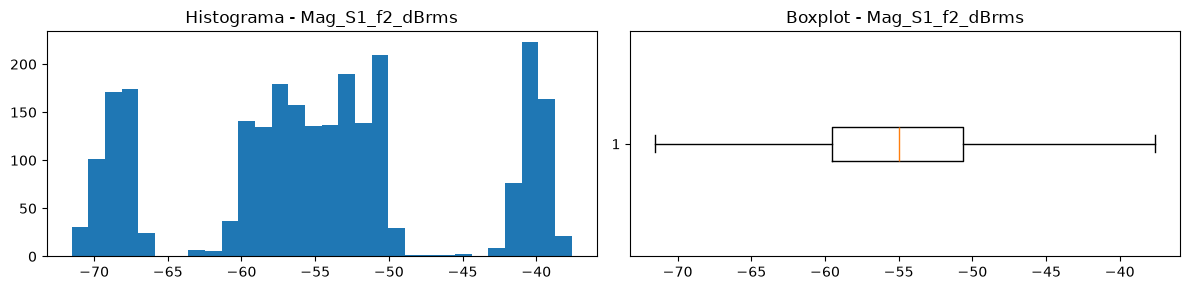

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


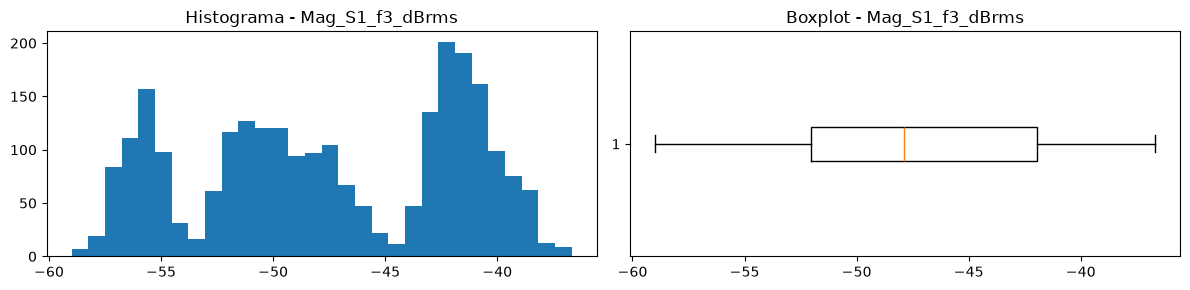

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


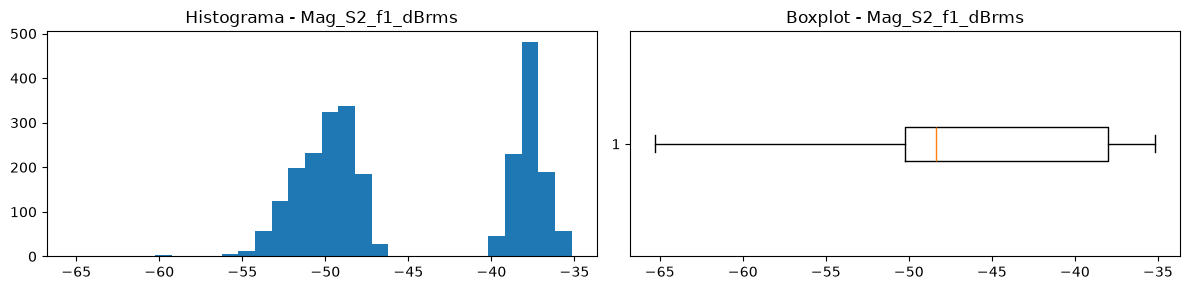

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


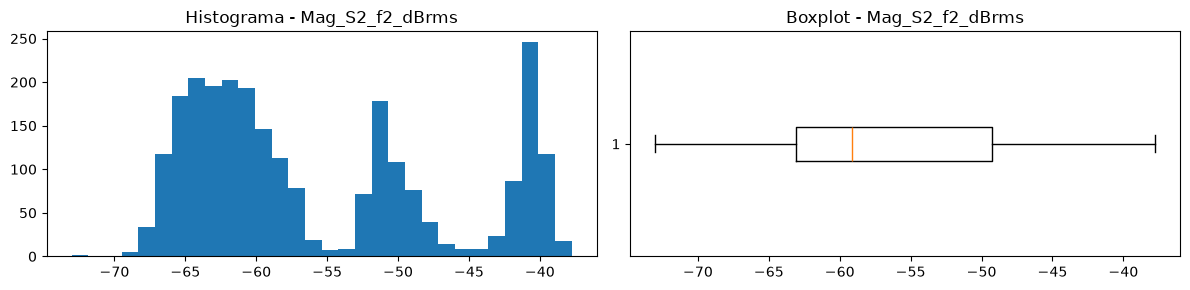

C:\Users\felip\AppData\Local\Temp\ipykernel_2188\542919618.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  eixos[1].boxplot(df[coluna], vert=False)


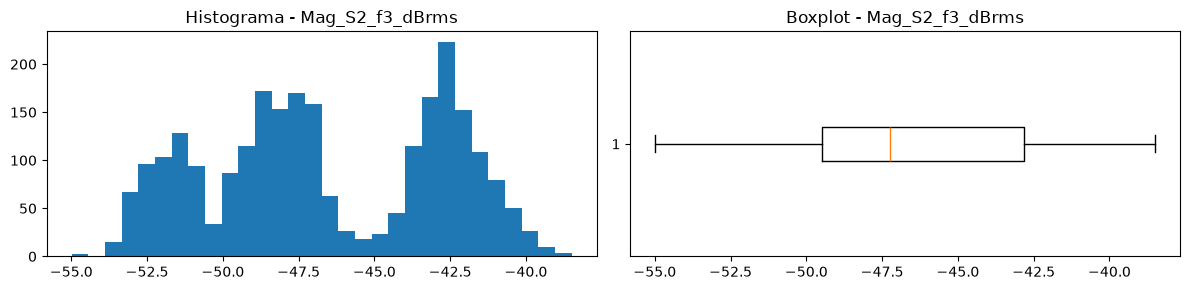

In [8]:
features = df.drop(columns=["tipo_setup", "tempo_s"]).columns

for coluna in features:
    fig, eixos = plt.subplots(1, 2, figsize=(12, 3))

    eixos[0].hist(df[coluna], bins=30)
    eixos[0].set_title("Histograma - " + coluna)

    eixos[1].boxplot(df[coluna], vert=False)
    eixos[1].set_title("Boxplot - " + coluna)

    plt.tight_layout()
    plt.show()

### Correlação entre as variáveis

Matriz de correlação de Pearson entre os 18 atributos, para identificar redundâncias entre variáveis e entre sensores.

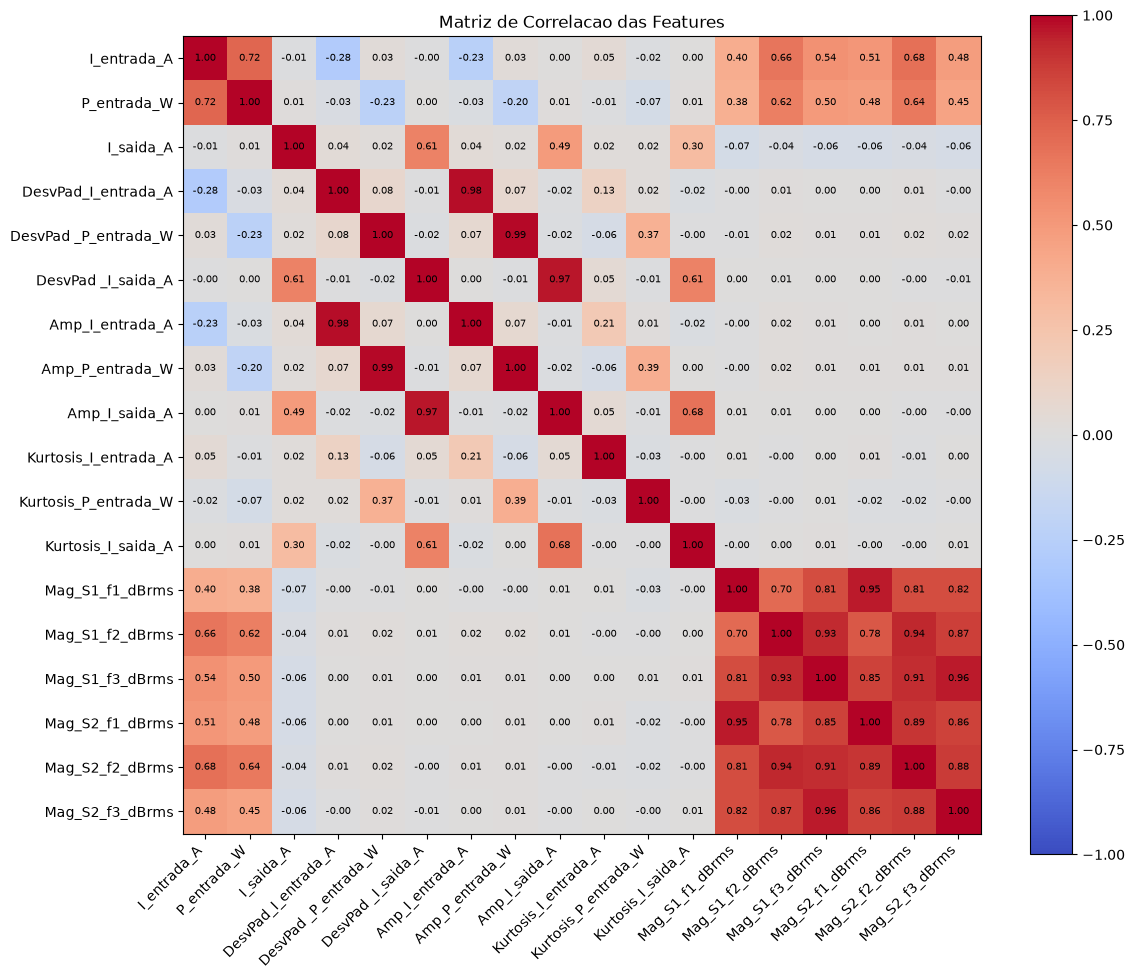

In [7]:
# Matriz de correlacao entre as features
df_corr = df.copy()
df_corr = df.drop(columns=["tipo_setup", "tempo_s"])
corr = df_corr.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
ax.set_title('Matriz de Correlacao das Features')
plt.tight_layout()
plt.show()

## Análise Exploratória: Principais Achados

**Classes balanceadas.** Cada classe possui 501 amostras (20%), o que torna a acurácia uma métrica confiável e justifica seu uso como métrica principal.

**Outliers.** As variáveis I_entrada_A e P_entrada_W apresentam um pico principal e um segundo agrupamento à direita, que o boxplot marca como outliers. Como esse comportamento é compatível com a condição de Sobrecarga, esses pontos provavelmente representam uma classe, e não erros de medição. Por isso, os "outliers" **não serão removidos**, já que isso poderia eliminar justamente a informação que distingue uma falha.

**Assimetria.** As variáveis DesvPad_I_entrada_A, DesvPad _P_entrada_W, Amp_I_entrada_A e Amp_P_entrada_W possuem cauda longa à direita. Será testada uma transformação logarítmica, com os modelos treinados com e sem ela para avaliar o impacto no desempenho.

**Vibração.** As magnitudes de vibração (Mag_S1_f1_dBrms a Mag_S2_f3_dBrms) apresentam distribuições multimodais, com grupos bem separados por intervalos vazios. Isso indica que cada condição operacional altera o padrão de vibração de forma distinta, tornando essas variáveis fortes candidatas a discriminar as classes. A modelagem verificará esse indício, comparando o desempenho de diferentes grupos de sensores.

**Correlação.** Os pares desvio padrão e amplitude do mesmo sinal são quase redundantes (por exemplo, DesvPad _P_entrada_W e Amp_P_entrada_W com correlação de 0,99), assim como os dois acelerômetros na mesma harmônica (Mag_S1_f1_dBrms e Mag_S2_f1_dBrms com 0,95, e Mag_S1_f3_dBrms e Mag_S2_f3_dBrms com 0,96). Essas variáveis não serão descartadas de início: a redundância será tratada pela seleção de variáveis dentro da pipeline e pela comparação entre grupos de sensores.

## Temporal Train-Test Split

O dataset não é um conjunto de amostras independentes: cada condição foi gravada de forma contínua, com um registro a cada 0,08 s. Como os atributos são calculados sobre janelas do sinal e a máquina não muda de estado em frações de segundo, linhas vizinhas são quase idênticas, o que é especialmente visível nas variáveis de vibração. Em uma divisão aleatória, essas amostras "gêmeas" ficam uma no treino e outra no teste, e o modelo acerta por já ter visto uma amostra praticamente igual, e não por ter aprendido o padrão da falha. Uma primeira versão do projeto usou a divisão aleatória e obteve resultados inflados, como será mostrado na seção de discussão.

Por isso, a divisão respeita o tempo:

- **Treino:** de 0 a 32 s de cada condição (400 amostras por classe, 2000 no total).
- **Teste:** de 32 a 40 s de cada condição (101 amostras por classe, 505 no total), **simulando a operação futura da máquina**.

As amostras gêmeas ficam do mesmo lado da divisão. Vizinhas dentro do próprio teste não afetam a avaliação, pois o modelo nunca treinou com elas.

A mesma lógica vale para a validação cruzada dentro do treino: os 32 s foram divididos em **4 blocos de 8 s** (`blocos_tempo`). Em cada fold, o modelo é validado em um bloco inteiro e treinado nos outros três (GroupKFold), garantindo que amostras gêmeas nunca fiquem separadas entre treino e validação.

In [8]:
df_treino = df[df["tempo_s"] < 32]
df_teste = df[df["tempo_s"] >= 32]

X_train = df_treino.drop(columns=["tipo_setup", "tempo_s"])
y_train = df_treino["tipo_setup"]

X_test = df_teste.drop(columns=["tipo_setup", "tempo_s"])
y_test = df_teste["tipo_setup"]

blocos_tempo = df_treino["tempo_s"] // 8

print(X_train.shape, X_test.shape)
print(y_train.value_counts().sort_index())
print(blocos_tempo.value_counts().sort_index())

(2000, 18) (505, 18)
tipo_setup
0.0    400
1.0    400
2.0    400
3.0    400
4.0    400
Name: count, dtype: int64
tempo_s
0.0    500
1.0    500
2.0    500
3.0    500
Name: count, dtype: int64


## Class Feature Distribution

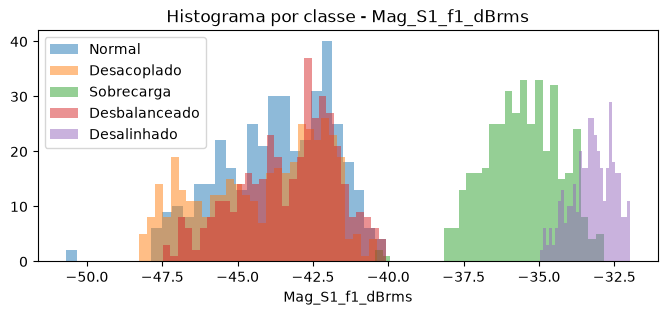

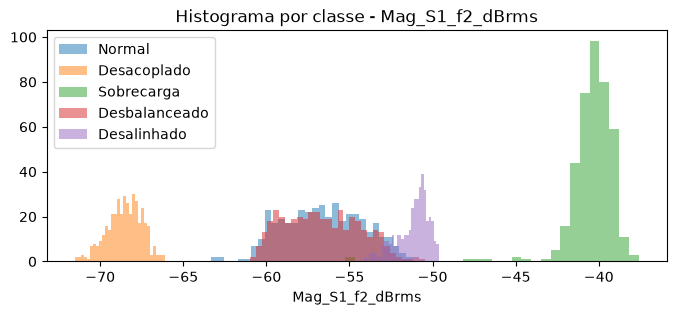

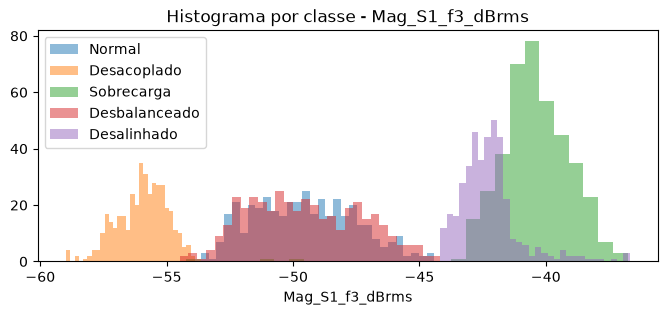

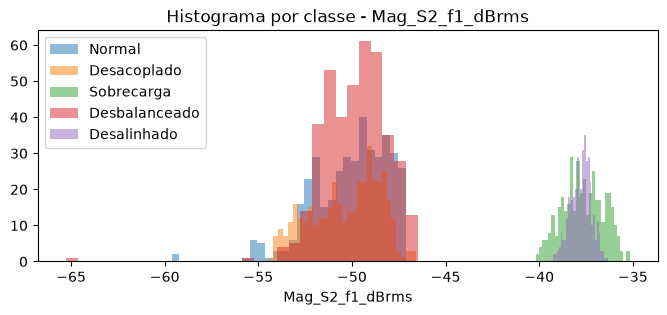

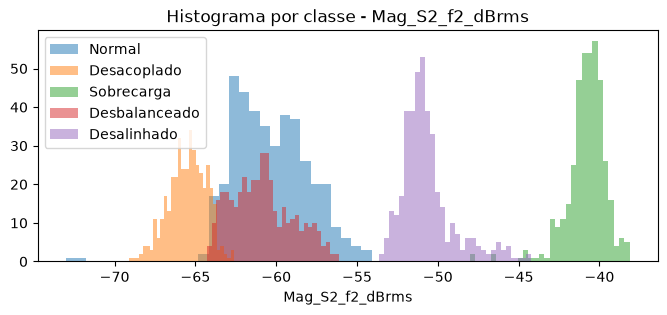

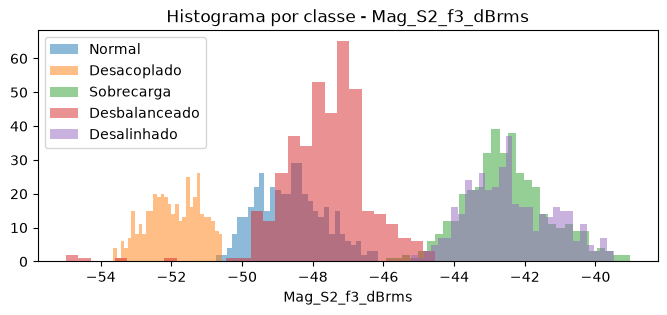

In [ ]:
vibracao = [
    "Mag_S1_f1_dBrms", "Mag_S1_f2_dBrms", "Mag_S1_f3_dBrms",
    "Mag_S2_f1_dBrms", "Mag_S2_f2_dBrms", "Mag_S2_f3_dBrms"
]

for coluna in vibracao:
    plt.figure(figsize=(8, 3))
    for classe in [0, 1, 2, 3, 4]:
        valores = X_train[coluna][y_train == classe]
        plt.hist(valores, bins=30, alpha=0.5, label=nomes_classes[classe])
    plt.xlabel(coluna)
    plt.title("Histograma por classe - " + coluna)
    plt.legend()
    plt.show()

**Distribuição das variáveis de vibração por classe (treino).** As magnitudes de vibração separam bem quatro das cinco condições. Mag_S2_f2_dBrms é a variável isolada mais discriminativa, distinguindo Desacoplado, Desalinhado e Sobrecarga. A condição Desacoplado apresenta vibração mais baixa nas harmônicas f2 e f3, coerente com o sistema sem carga, enquanto Sobrecarga e Desalinhado se destacam na frequência fundamental f1 e se diferenciam entre si em f2. Já Normal e Desbalanceado se sobrepõem em praticamente todas as variáveis de vibração, contrariando a expectativa de que o desbalanceamento elevaria a vibração em f1. Espera-se, portanto, que os erros dos modelos se concentrem nesse par. Os resultados reforçam H1 e dão indícios a favor de H2, a serem confirmados na modelagem com a comparação entre grupos de sensores.

## Pré-processar os Dados

Todas as transformações são aplicadas dentro de uma **Pipeline** do scikit-learn e, por isso, são ajustadas apenas com os dados de treino de cada fold, sem vazamento de informação para a validação ou o teste.

**Limpeza.** O dataset não possui valores nulos. Os outliers foram mantidos, pois representam condições de falha (seção de exploração). A coluna tempo_s foi removida dos atributos, por indicar apenas o instante da gravação, e não uma grandeza física da máquina.

**Novas características.** As variáveis de cauda longa (DesvPad_I_entrada_A, DesvPad _P_entrada_W, Amp_I_entrada_A e Amp_P_entrada_W) recebem uma transformação logarítmica (log10), implementada no transformador SimpleLog1pTransformer.

**Padronização.** Todas as variáveis são padronizadas com StandardScaler (média zero e desvio padrão um). Isso é necessário para modelos sensíveis à escala, como Regressão Logística, KNN e SVM, e para a seleção de variáveis com penalidade L1.

**Seleção de características.** É feita com SelectFromModel usando uma Regressão Logística com penalidade L1 (Lasso), que zera os coeficientes das variáveis pouco úteis. Uma variável é descartada apenas se o coeficiente for zero para as cinco classes (threshold de 1e-5). Por estar dentro da pipeline, a seleção é refeita em cada fold. O valor de C = 0,36 foi obtido em uma análise exploratória preliminar e indica regularização moderada. Nessa análise, foram removidas as três variáveis Amp_ (redundantes com as DesvPad_ correspondentes) e Kurtosis_I_entrada_A, o que é coerente com a matriz de correlação.

**Grupos de sensores.** Para testar a H2, foram definidos cinco grupos de atributos com base no domínio: todos os sinais, só elétricos, só vibração (dois acelerômetros), só o sensor 1 e só o sensor 2.

A transformação log e a seleção de variáveis são tratadas como uma única opção (processado: com ou sem), e tanto essa opção quanto o grupo de sensores são escolhidos pelo Optuna na etapa de modelagem.

### Grupos de sensores

Definição dos cinco grupos de atributos usados para testar a H2.

In [10]:
eletricas = [
    "I_entrada_A", "P_entrada_W", "I_saida_A",
    "DesvPad_I_entrada_A", "DesvPad _P_entrada_W", "DesvPad _I_saida_A",
    "Amp_I_entrada_A", "Amp_P_entrada_W", "Amp_I_saida_A",
    "Kurtosis_I_entrada_A", "Kurtosis_P_entrada_W", "Kurtosis_I_saida_A"
]

sensor1 = ["Mag_S1_f1_dBrms", "Mag_S1_f2_dBrms", "Mag_S1_f3_dBrms"]
sensor2 = ["Mag_S2_f1_dBrms", "Mag_S2_f2_dBrms", "Mag_S2_f3_dBrms"]

grupos = {
    "Todos": eletricas + sensor1 + sensor2,
    "Eletricos": eletricas,
    "Vibracao": sensor1 + sensor2,
    "S1": sensor1,
    "S2": sensor2
}

for nome in grupos:
    print(nome, len(grupos[nome]))

Todos 18
Eletricos 12
Vibracao 6
S1 3
S2 3


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

### Transformador logarítmico

Transformador customizado que aplica log10 às colunas de cauda longa.

In [12]:
class SimpleLog1pTransformer(BaseEstimator, TransformerMixin):
    """Aplica np.log1p (log(1+x)) a uma lista de colunas especificadas."""

    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        
        return self

    def transform(self, X, y=None):
        """Aplica log1p às colunas especificadas."""

        X_transformed = X.copy()
        for col in self.columns:
            X_transformed[col] = np.where(
            X_transformed[col] > 0,
            np.log10(X_transformed[col]),
            np.log10(X_transformed[col] + 1) 
            )

        return X_transformed

    def get_feature_names_out(self, input_features=None):
        """Retorna os nomes das features."""

        if input_features is None:
           
            if hasattr(self, 'columns'):
                 
                 return self.columns
            else:
                 raise ValueError("Input feature names are required.")
        return input_features

colunas_log = [
    "DesvPad_I_entrada_A", "DesvPad _P_entrada_W",
    "Amp_I_entrada_A", "Amp_P_entrada_W"
]

### Pipeline de pré-processamento e modelo

Função que monta a pipeline com log e seleção de variáveis opcionais, padronização e o modelo de classificação.

In [ ]:
def build_pipeline(model, columns, log=False, selection=False):
    """
    Cria uma pipeline com transformação log e seleção de variáveis
    opcionais, padronização e o modelo de classificação.
    """
    steps = []

    if log:
        log_columns = []
        for col in colunas_log:
            if col in columns:
                log_columns.append(col)

        if len(log_columns) > 0:
            log_transformer = SimpleLog1pTransformer(columns=log_columns)
            steps.append(('log', log_transformer))

    steps.append(('scaler', StandardScaler()))

    if selection:
        selector_model = LogisticRegression(
            l1_ratio=1.0,
            C=0.36,
            solver='saga',
            max_iter=5000,
            random_state=42
        )
        steps.append(('selection', SelectFromModel(selector_model, threshold=1e-5)))

    steps.append(('model', model))

    final_pipeline = Pipeline(steps=steps)

    return final_pipeline

## Desenvolver Modelo

In [14]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

cv = GroupKFold(n_splits=4)

### Modelos avaliados

Foram avaliados seis modelos, de complexidade crescente:

- **Dummy:** classificador que ignora os atributos e serve como piso de desempenho (cerca de 20% com 5 classes balanceadas).
- **Regressão Logística:** modelo linear, simples e interpretável.
- **KNN:** classifica pela classe dos vizinhos mais próximos.
- **SVM (kernel RBF):** busca a fronteira de maior margem entre as classes, podendo ser não linear.
- **Árvore de Decisão:** regras de decisão interpretáveis.
- **Random Forest:** conjunto de árvores, mais robusto que uma árvore isolada.

Cada modelo tem uma função de criação que recebe os hiperparâmetros como dicionário, o que permite reutilizá-la na otimização e na reconstrução do modelo final.

In [15]:
from sklearn.dummy import DummyClassifier

def create_dummy_model(params):
    return DummyClassifier(strategy=params['strategy'], random_state=42)

def create_logreg_model(params):
    return LogisticRegression(C=params['C'], max_iter=5000, random_state=42)

def create_knn_model(params):
    return KNeighborsClassifier(
        n_neighbors=params['n_neighbors'],
        weights=params['weights'],
        p=params['p']
    )

def create_svm_model(params, probability=False):
    return SVC(
        C=params['C'],
        gamma=params['gamma'],
        kernel='rbf',
        probability=probability,
        random_state=42
    )

def create_tree_model(params):
    return DecisionTreeClassifier(
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        criterion=params['criterion'],
        random_state=42
    )

def create_rf_model(params):
    return RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        random_state=42
    )

### Otimização com Optuna

Para cada modelo, um estudo do Optuna busca a melhor combinação de três tipos de parâmetro:

1. **Grupo de sensores:** Todos, Elétricos, Vibração, S1 ou S2.
2. **Pré-processamento:** com ou sem transformação log e seleção de variáveis.
3. **Hiperparâmetros do modelo:** C na Regressão Logística; número de vizinhos, ponderação e distância no KNN; C e gamma no SVM; profundidade, mínimo de amostras por folha e critério na Árvore; e número de árvores, profundidade, mínimo por folha e número de atributos por divisão no Random Forest.

Cada combinação é avaliada pela **acurácia média na validação cruzada com 4 blocos de tempo** (GroupKFold), usando apenas os dados de treino. Foram executados 100 trials por modelo (3 para o Dummy, que só tem uma opção).

In [16]:
def suggest_common(trial):
    """Sugere o grupo de sensores e se usa log + seleção de variáveis."""
    grupo = trial.suggest_categorical('grupo', list(grupos.keys()))
    processado = trial.suggest_categorical('processado', [True, False])
    return grupo, processado

def evaluate(model, grupo, processado):
    """Monta a pipeline e retorna a acurácia média da validação cruzada por blocos de tempo."""
    colunas = grupos[grupo]
    pipeline = build_pipeline(model, colunas, log=processado, selection=processado)

    scores = cross_val_score(
        pipeline,
        X_train[colunas],
        y_train,
        cv=cv,
        groups=blocos_tempo,
        scoring='accuracy',
        n_jobs=-1,
        error_score='raise'
    )
    return scores.mean()

In [17]:
def objective_dummy(trial):
    params = {'strategy': trial.suggest_categorical('strategy', ['most_frequent', 'stratified', 'uniform'])}
    model = create_dummy_model(params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, groups=blocos_tempo, scoring='accuracy')
    return scores.mean()

def objective_logreg(trial):
    grupo, processado = suggest_common(trial)
    params = {'C': trial.suggest_float('C', 1e-3, 1e2, log=True)}
    return evaluate(create_logreg_model(params), grupo, processado)

def objective_knn(trial):
    grupo, processado = suggest_common(trial)
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 30),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p': trial.suggest_categorical('p', [1, 2])
    }
    return evaluate(create_knn_model(params), grupo, processado)

def objective_svm(trial):
    grupo, processado = suggest_common(trial)
    params = {
        'C': trial.suggest_float('C', 1e-2, 1e3, log=True),
        'gamma': trial.suggest_float('gamma', 1e-4, 1e1, log=True)
    }
    return evaluate(create_svm_model(params), grupo, processado)

def objective_tree(trial):
    grupo, processado = suggest_common(trial)
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
    }
    return evaluate(create_tree_model(params), grupo, processado)

def objective_rf(trial):
    grupo, processado = suggest_common(trial)
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    return evaluate(create_rf_model(params), grupo, processado)

In [18]:
def run_study(objective, n_trials, nome):
    """Roda um estudo do Optuna maximizando o accuracy."""
    print("Iniciando otimização:", nome)
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)

    print("  Melhor accuracy (CV):", round(study.best_value, 5))
    print("  Parâmetros:", study.best_params)
    return study

### Execução dos estudos

In [19]:
studies = {}

studies['Dummy'] = run_study(objective_dummy, 3, 'Dummy')
studies['LogReg'] = run_study(objective_logreg, 100, 'Regressão Logística')
studies['KNN'] = run_study(objective_knn, 100, 'KNN')
studies['SVM'] = run_study(objective_svm, 100, 'SVM')
studies['Tree'] = run_study(objective_tree, 100, 'Decision Tree')
studies['RF'] = run_study(objective_rf, 100, 'Random Forest')

Iniciando otimização: Dummy
  Melhor accuracy (CV): 0.204
  Parâmetros: {'strategy': 'stratified'}
Iniciando otimização: Regressão Logística
  Melhor accuracy (CV): 0.9225
  Parâmetros: {'grupo': 'Todos', 'processado': False, 'C': 0.5790228092377597}
Iniciando otimização: KNN
  Melhor accuracy (CV): 0.8885
  Parâmetros: {'grupo': 'Vibracao', 'processado': False, 'n_neighbors': 3, 'weights': 'distance', 'p': 2}
Iniciando otimização: SVM
  Melhor accuracy (CV): 0.9325
  Parâmetros: {'grupo': 'Todos', 'processado': False, 'C': 828.9747038485955, 'gamma': 0.0001314234221090433}
Iniciando otimização: Decision Tree
  Melhor accuracy (CV): 0.8835
  Parâmetros: {'grupo': 'Vibracao', 'processado': False, 'max_depth': 16, 'min_samples_leaf': 8, 'criterion': 'entropy'}
Iniciando otimização: Random Forest
  Melhor accuracy (CV): 0.9095
  Parâmetros: {'grupo': 'Todos', 'processado': True, 'n_estimators': 447, 'max_depth': 18, 'min_samples_leaf': 3, 'max_features': 'sqrt'}


**Melhores trials por modelo.** Os três modelos de melhor desempenho (SVM, Regressão Logística e Random Forest) escolheram o grupo com todos os sinais, enquanto KNN e Árvore de Decisão, os de pior desempenho, preferiram apenas a vibração. Os cinco melhores trials de cada modelo têm acurácias praticamente iguais e o mesmo grupo de sensores, o que indica que a escolha é estável. Na maioria dos casos, o pré-processamento com log e seleção não trouxe ganho: nos grupos só de vibração o log não atua, e a seleção pouco acrescenta com poucas variáveis. Esses resultados já sugerem que os sinais elétricos contribuem para o desempenho, o que é avaliado em detalhe na discussão da H2.

In [20]:
for nome in studies:
    if nome == 'Dummy':
        continue

    df_trials = studies[nome].trials_dataframe()
    df_trials = df_trials.sort_values('value', ascending=False)

    colunas_exibir = ['value', 'params_grupo', 'params_processado']

    print(nome)
    display(df_trials[colunas_exibir].head(5))

LogReg


,value,params_grupo,params_processado
31,0.9225,Todos,False
68,0.9225,Todos,False
43,0.9220,Todos,False
61,0.9220,Todos,False
44,0.9220,Todos,False


KNN


,value,params_grupo,params_processado
57,0.8885,Vibracao,True
56,0.8885,Vibracao,True
61,0.8885,Vibracao,True
41,0.8885,Vibracao,False
70,0.8885,Vibracao,True


SVM


,value,params_grupo,params_processado
81,0.9325,Todos,False
84,0.9325,Todos,False
97,0.9320,Todos,False
82,0.9320,Todos,False
89,0.9315,Todos,False


Tree


,value,params_grupo,params_processado
77,0.8835,Vibracao,False
87,0.8835,Vibracao,False
44,0.8835,Vibracao,False
37,0.8835,Vibracao,False
91,0.8835,Vibracao,False


RF


,value,params_grupo,params_processado
93,0.9095,Todos,True
82,0.9090,Todos,True
75,0.9090,Todos,True
96,0.9090,Todos,True
80,0.9090,Todos,True


### Reconstrução dos modelos com os melhores parâmetros

Cada modelo é reconstruído com o grupo de sensores, o pré-processamento e os hiperparâmetros do seu melhor trial.

In [21]:
final_models = {}
final_colunas = {}

params = studies['Dummy'].best_params
final_models['Dummy'] = create_dummy_model(params)
final_colunas['Dummy'] = grupos['Todos']

params = studies['LogReg'].best_params
final_colunas['LogReg'] = grupos[params['grupo']]
final_models['LogReg'] = build_pipeline(create_logreg_model(params), final_colunas['LogReg'], params['processado'], params['processado'])

params = studies['KNN'].best_params
final_colunas['KNN'] = grupos[params['grupo']]
final_models['KNN'] = build_pipeline(create_knn_model(params), final_colunas['KNN'], params['processado'], params['processado'])

params = studies['SVM'].best_params
final_colunas['SVM'] = grupos[params['grupo']]
final_models['SVM'] = build_pipeline(create_svm_model(params, probability=True), final_colunas['SVM'], params['processado'], params['processado'])

params = studies['Tree'].best_params
final_colunas['Tree'] = grupos[params['grupo']]
final_models['Tree'] = build_pipeline(create_tree_model(params), final_colunas['Tree'], params['processado'], params['processado'])

params = studies['RF'].best_params
final_colunas['RF'] = grupos[params['grupo']]
final_models['RF'] = build_pipeline(create_rf_model(params), final_colunas['RF'], params['processado'], params['processado'])

for nome in final_models:
    print(nome, "->", len(final_colunas[nome]), "colunas")

Dummy -> 18 colunas
LogReg -> 18 colunas
KNN -> 6 colunas
SVM -> 18 colunas
Tree -> 6 colunas
RF -> 18 colunas


In [22]:
from sklearn.model_selection import cross_validate

metricas = ['accuracy', 'recall_macro', 'f1_macro', 'precision_macro']

### Validação cruzada dos modelos otimizados

Avaliação dos modelos reconstruídos com a mesma validação cruzada por blocos de tempo, calculando acurácia, recall, precisão e F1-score macro.

In [23]:
cv_scores = {}

for nome in final_models:
    print("Avaliando:", nome)
    colunas = final_colunas[nome]

    resultado = cross_validate(
        final_models[nome],
        X_train[colunas],
        y_train,
        cv=cv,
        groups=blocos_tempo,
        scoring=metricas,
        n_jobs=-1
    )

    cv_scores[nome] = resultado

Avaliando: Dummy
Avaliando: LogReg
Avaliando: KNN
Avaliando: SVM
Avaliando: Tree
Avaliando: RF


In [24]:
linhas = []

for nome in cv_scores:
    linha = {'Modelo': nome}
    for metrica in metricas:
        valores = cv_scores[nome]['test_' + metrica]
        linha[metrica + '_media'] = valores.mean()
        # linha[metrica + '_desvio'] = valores.std()
    linhas.append(linha)

tabela_cv = pd.DataFrame(linhas)
tabela_cv = tabela_cv.sort_values('accuracy_media', ascending=False)
tabela_cv.round(4)

,Modelo,accuracy_media,recall_macro_media,f1_macro_media,precision_macro_media
3,SVM,0.9325,0.9325,0.9318,0.9379
1,LogReg,0.9225,0.9225,0.9220,0.9259
5,RF,0.9095,0.9095,0.9087,0.9151
2,KNN,0.8885,0.8885,0.8867,0.8970
4,Tree,0.8835,0.8835,0.8825,0.8870
0,Dummy,0.2040,0.2040,0.2032,0.2031


**Resultados da validação cruzada.** O SVM obteve o melhor desempenho (93,3%), seguido pela Regressão Logística (92,3%) e pelo Random Forest (91,0%). KNN (88,9%) e Árvore de Decisão (88,4%) ficaram abaixo, e todos superaram amplamente o Dummy (20,4%). Como esperado para classes balanceadas, acurácia, recall, precisão e F1-score macro têm valores praticamente iguais para cada modelo.

In [25]:
tabela_cv.to_csv("resultados_cv_temporal.csv", index=False)

### Validação temporal dos candidatos

Para escolher os modelos que seguem para o teste, três candidatos (Regressão Logística, SVM e KNN) foram comparados em uma validação holdout que também respeita o tempo: treino de 0 a 25,6 s (1600 amostras) e validação de 25,6 a 32 s (400 amostras, 80 por classe). Diferentemente da validação cruzada, que retorna apenas um número por fold, essa etapa gera a predição de cada amostra, permitindo analisar a matriz de confusão e a curva ROC. O conjunto de teste não é usado aqui.

In [27]:
from sklearn.base import clone

sub_treino = df_treino[df_treino["tempo_s"] < 25.6]
validacao = df_treino[df_treino["tempo_s"] >= 25.6]

X_sub = sub_treino.drop(columns=["tipo_setup", "tempo_s"])
y_sub = sub_treino["tipo_setup"]

X_val = validacao.drop(columns=["tipo_setup", "tempo_s"])
y_val = validacao["tipo_setup"]

print(X_sub.shape, X_val.shape)
print(y_val.value_counts().sort_index())

(1600, 18) (400, 18)
tipo_setup
0.0    80
1.0    80
2.0    80
3.0    80
4.0    80
Name: count, dtype: int64


In [29]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

modelos_validacao = ['LogReg', 'SVM', 'KNN']

predicoes_val = {}
probabilidades_val = {}
linhas_val = []

for nome in modelos_validacao:
    colunas = final_colunas[nome]
    modelo = clone(final_models[nome])

    modelo.fit(X_sub[colunas], y_sub)
    y_pred = modelo.predict(X_val[colunas])

    predicoes_val[nome] = y_pred
    probabilidades_val[nome] = modelo.predict_proba(X_val[colunas])

    linha = {
        'Modelo': nome,
        'accuracy': accuracy_score(y_val, y_pred),
        'recall_macro': recall_score(y_val, y_pred, average='macro'),
        'precision_macro': precision_score(y_val, y_pred, average='macro'),
        'f1_macro': f1_score(y_val, y_pred, average='macro')
    }
    linhas_val.append(linha)

tabela_val = pd.DataFrame(linhas_val)
tabela_val = tabela_val.sort_values('accuracy', ascending=False)
tabela_val.round(4)

c:\Users\felip\OneDrive\Documentos\7-semestre\IA_p_auto\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Modelo,accuracy,recall_macro,precision_macro,f1_macro
2,KNN,0.9550,0.9550,0.9599,0.9547
1,SVM,0.9325,0.9325,0.9404,0.9315
0,LogReg,0.9225,0.9225,0.9283,0.9216


**Métricas na validação.** O KNN obteve a maior acurácia (95,5%), seguido pelo SVM (93,3%) e pela Regressão Logística (92,3%). Chama atenção que o KNN teve 88,9% na validação cruzada, o que indica que seu desempenho varia mais entre trechos de tempo do que o dos outros modelos. O SVM manteve exatamente o mesmo valor da validação cruzada.

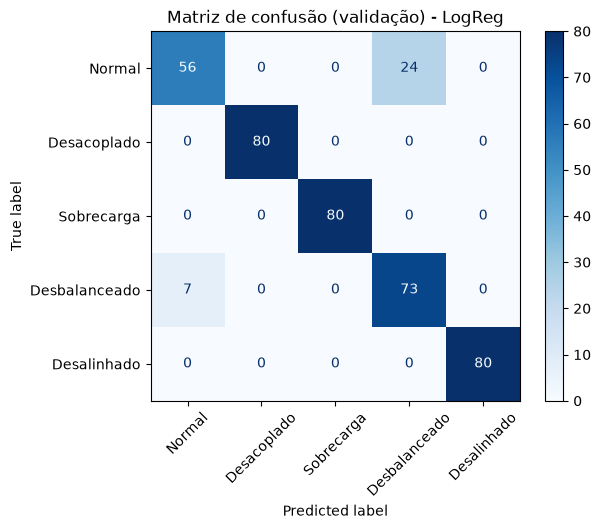

LogReg - falhas classificadas como Normal: 7 de 320


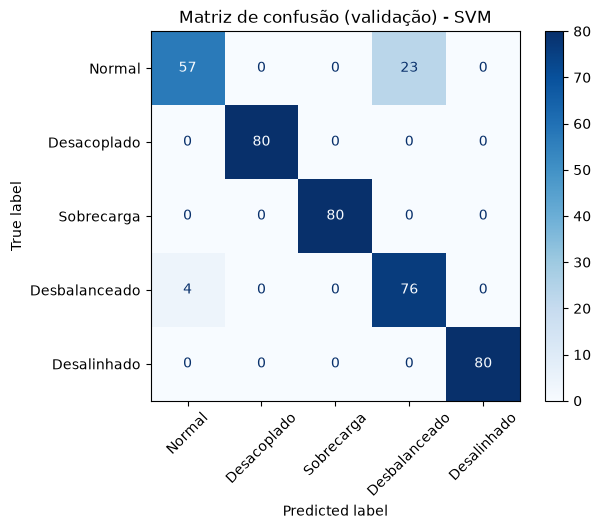

SVM - falhas classificadas como Normal: 4 de 320


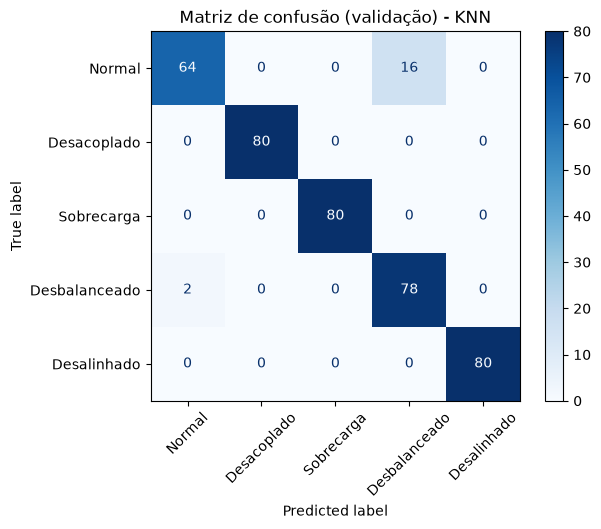

KNN - falhas classificadas como Normal: 2 de 320


In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for nome in modelos_validacao:
    matriz = confusion_matrix(y_val, predicoes_val[nome])

    ConfusionMatrixDisplay(matriz, display_labels=nomes_classes).plot(cmap='Blues')
    plt.title("Matriz de confusão (validação) - " + nome)
    plt.xticks(rotation=45)
    plt.show()

    falhas_como_normal = matriz[1:, 0].sum()
    print(nome, "- falhas classificadas como Normal:", falhas_como_normal, "de 320")

**Matrizes de confusão na validação.** Nos três modelos, os erros estão todos no par Normal e Desbalanceado, como previsto na exploração dos dados. As condições Desacoplado, Sobrecarga e Desalinhado foram classificadas com 100% de acerto. A maior parte dos erros é Normal previsto como Desbalanceado, ou seja, alarme falso, que é o erro de menor custo. O erro crítico, falha prevista como Normal, foi raro: 2 casos no KNN, 4 no SVM e 7 na Regressão Logística, de 320 amostras de falha.

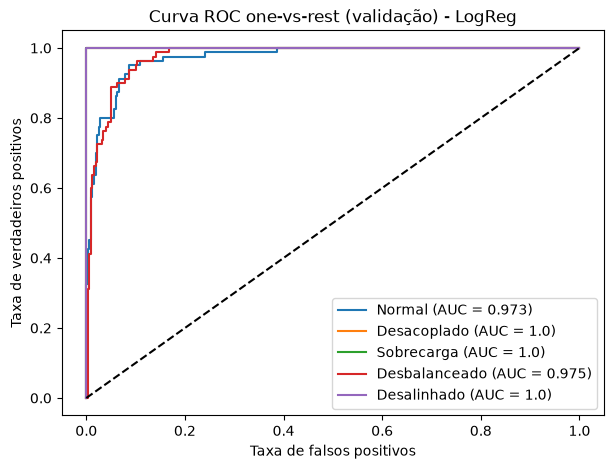

LogReg - AUC macro: 0.9896


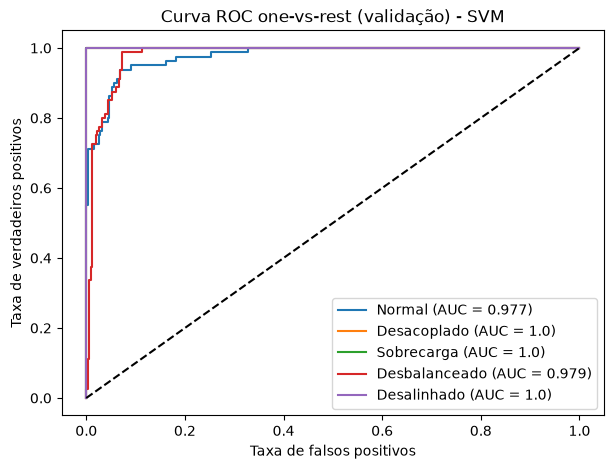

SVM - AUC macro: 0.9912


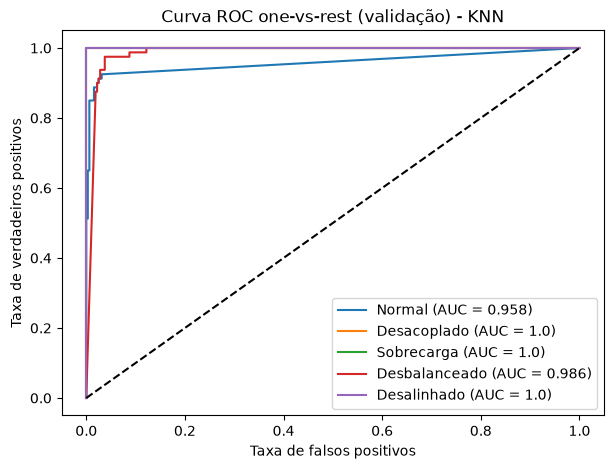

KNN - AUC macro: 0.9888


In [31]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

y_val_bin = label_binarize(y_val, classes=[0, 1, 2, 3, 4])

for nome in modelos_validacao:
    probas = probabilidades_val[nome]

    plt.figure(figsize=(7, 5))
    for i in range(5):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], probas[:, i])
        area = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=nomes_classes[i] + " (AUC = " + str(round(area, 3)) + ")")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("Taxa de falsos positivos")
    plt.ylabel("Taxa de verdadeiros positivos")
    plt.title("Curva ROC one-vs-rest (validação) - " + nome)
    plt.legend()
    plt.show()

    auc_macro = roc_auc_score(y_val, probas, multi_class='ovr', average='macro')
    print(nome, "- AUC macro:", round(auc_macro, 4))

**Curvas ROC na validação.** As AUCs macro são altas nos três modelos (SVM 0,991, Regressão Logística 0,990 e KNN 0,989). Desacoplado, Sobrecarga e Desalinhado têm AUC igual a 1,0, e as menores AUCs estão em Normal e Desbalanceado, confirmando que esse é o único par difícil. O KNN tem a menor AUC para Normal (0,958), pois, com apenas 3 vizinhos, suas probabilidades assumem poucos valores possíveis, o que torna a ordenação das amostras menos refinada.

### Escolha dos modelos para o teste

Com base na validação cruzada e na validação temporal, e **antes de qualquer uso do conjunto de teste**, foram escolhidos dois modelos:

- **SVM:** melhor desempenho na validação cruzada e o mais estável entre as etapas (93,3% nas duas), usando todos os sinais.
- **KNN:** melhor desempenho na validação temporal e menor número de falhas previstas como Normal, usando apenas os dois acelerômetros. É a alternativa com menos sensores, relevante para a H2.

A Regressão Logística também seria uma escolha válida, por ser a mais simples e interpretável e ficar cerca de 1 ponto atrás do SVM, mas optou-se por levar ao teste o modelo mais forte e a alternativa com menos sensores. Os dois são treinados no treino completo (0 a 32 s) e avaliados uma única vez no teste (32 a 40 s).

In [34]:
modelos_teste = ['KNN', 'SVM']

predicoes_teste = {}
linhas_teste = []

for nome in modelos_teste:
    colunas = final_colunas[nome]

    final_models[nome].fit(X_train[colunas], y_train)
    y_pred = final_models[nome].predict(X_test[colunas])
    predicoes_teste[nome] = y_pred

    linha = {
        'Modelo': nome,
        'accuracy': accuracy_score(y_test, y_pred),
        'recall_macro': recall_score(y_test, y_pred, average='macro'),
        'precision_macro': precision_score(y_test, y_pred, average='macro'),
        'f1_macro': f1_score(y_test, y_pred, average='macro')
    }
    linhas_teste.append(linha)

tabela_teste = pd.DataFrame(linhas_teste)
tabela_teste.to_csv("resultados_teste_temporal.csv", index=False)
tabela_teste.round(4)

c:\Users\felip\OneDrive\Documentos\7-semestre\IA_p_auto\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Modelo,accuracy,recall_macro,precision_macro,f1_macro
0,KNN,0.8911,0.8911,0.8915,0.8910
1,SVM,0.9109,0.9109,0.9241,0.9084


**Métricas no teste.** O SVM obteve 91,1% de acurácia e o KNN, 89,1%. O SVM manteve desempenho próximo ao da validação cruzada (93,3%), enquanto a vantagem do KNN na validação temporal (95,5%) não se sustentou: seu resultado no teste ficou alinhado ao da validação cruzada (88,9%). Isso mostra que uma única janela de validação pode ser enganosa, e que a validação cruzada com vários blocos de tempo foi a melhor previsão do desempenho real.

In [35]:
from sklearn.metrics import classification_report

for nome in modelos_teste:
    print(nome)
    print(classification_report(y_test, predicoes_teste[nome], target_names=nomes_classes))

KNN
               precision    recall  f1-score   support

       Normal       0.74      0.69      0.72       101
  Desacoplado       1.00      1.00      1.00       101
   Sobrecarga       1.00      1.00      1.00       101
Desbalanceado       0.71      0.76      0.74       101
  Desalinhado       1.00      1.00      1.00       101

     accuracy                           0.89       505
    macro avg       0.89      0.89      0.89       505
 weighted avg       0.89      0.89      0.89       505

SVM
               precision    recall  f1-score   support

       Normal       0.91      0.61      0.73       101
  Desacoplado       1.00      1.00      1.00       101
   Sobrecarga       1.00      1.00      1.00       101
Desbalanceado       0.71      0.94      0.81       101
  Desalinhado       1.00      1.00      1.00       101

     accuracy                           0.91       505
    macro avg       0.92      0.91      0.91       505
 weighted avg       0.92      0.91      0.91       5

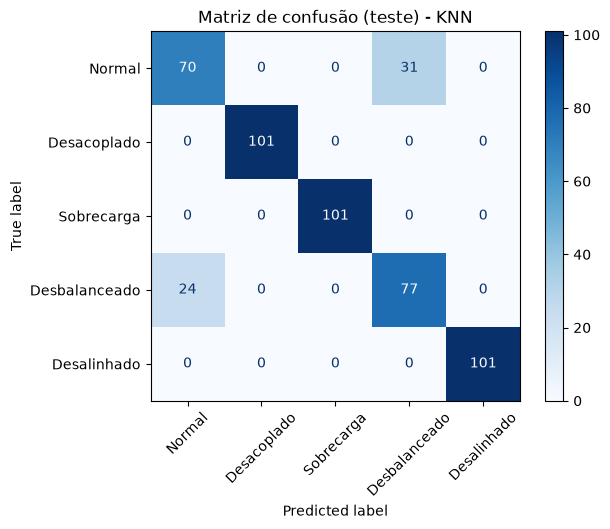

KNN - falhas classificadas como Normal: 24 de 404


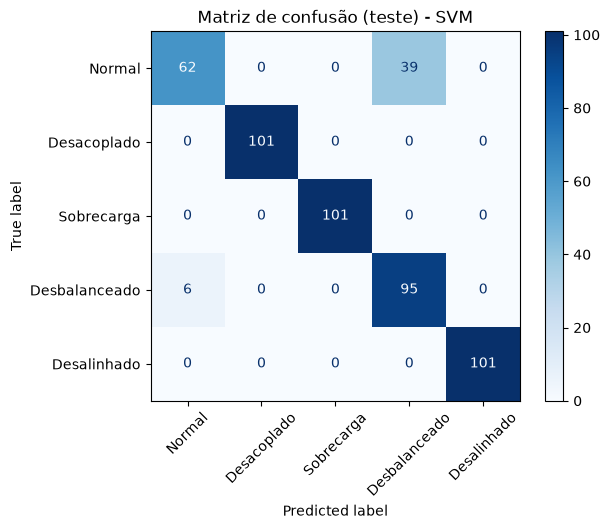

SVM - falhas classificadas como Normal: 6 de 404


In [36]:
for nome in modelos_teste:
    matriz_teste = confusion_matrix(y_test, predicoes_teste[nome])

    ConfusionMatrixDisplay(matriz_teste, display_labels=nomes_classes).plot(cmap='Blues')
    plt.title("Matriz de confusão (teste) - " + nome)
    plt.xticks(rotation=45)
    plt.show()

    falhas_como_normal = matriz_teste[1:, 0].sum()
    print(nome, "- falhas classificadas como Normal:", falhas_como_normal, "de 404")

**Matrizes de confusão no teste.** Assim como na validação, os erros se concentram exclusivamente no par Normal e Desbalanceado, e as outras três condições têm 100% de acerto. A diferença entre os modelos está no tipo de erro:

| Modelo | Acurácia | Falhas previstas como Normal (de 404) | Normal previsto como Desbalanceado (alarme falso) |
|---|---|---|---|
| SVM | 91,1% | 6 | 39 |
| KNN | 89,1% | 24 | 31 |

O SVM erra "para o lado seguro": a maior parte dos seus erros é alarme falso, e o recall de Desbalanceado chega a 0,94, contra 0,76 do KNN. O KNN deixa passar quatro vezes mais falhas, que é o erro de maior custo no contexto industrial. Por isso, o **SVM é escolhido como modelo final**, e o KNN fica como alternativa de menor custo de instrumentação, com essa perda quantificada.

## Função de Classificação

### Re-treino dos modelos finais

Após a avaliação no teste, os modelos SVM e KNN são re-treinados com o dataset completo (2505 amostras), com os mesmos hiperparâmetros, para que o modelo colocado em uso aprenda com todos os dados disponíveis. As métricas reportadas continuam sendo as do teste, que medem o desempenho do modelo treinado apenas com o treino. Com mais dados, espera-se desempenho igual ou superior.

In [37]:
X_completo = df.drop(columns=["tipo_setup", "tempo_s"])
y_completo = df["tipo_setup"]

modelos_producao = {}

for nome in ['SVM', 'KNN']:
    colunas = final_colunas[nome]
    modelo = clone(final_models[nome])
    modelo.fit(X_completo[colunas], y_completo)
    modelos_producao[nome] = modelo
    print(nome, "treinado com", len(X_completo), "amostras e", len(colunas), "atributos")

c:\Users\felip\OneDrive\Documentos\7-semestre\IA_p_auto\venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM treinado com 2505 amostras e 18 atributos
KNN treinado com 2505 amostras e 6 atributos


### Função para classificação de falhas

A função `classificar_falha` recebe um dicionário com os valores dos 18 atributos e o nome do modelo ('SVM', padrão, ou 'KNN') e retorna a condição operacional prevista: Normal, Desacoplado, Sobrecarga, Desbalanceado ou Desalinhado. O KNN utiliza apenas os 6 atributos de vibração e ignora os demais. A função verifica se todos os atributos necessários foram informados antes de classificar.

In [38]:
def classificar_falha(atributos, nome_modelo='SVM'):
    """
    Recebe um dicionário com os valores dos 18 atributos e o nome do
    modelo ('SVM' ou 'KNN') e retorna a condição operacional prevista.
    """
    if nome_modelo not in modelos_producao:
        raise ValueError("Modelo inválido. Use 'SVM' ou 'KNN'.")

    colunas = final_colunas[nome_modelo]

    faltando = []
    for coluna in colunas:
        if coluna not in atributos:
            faltando.append(coluna)

    if len(faltando) > 0:
        raise ValueError("Atributos faltando: " + str(faltando))

    entrada = pd.DataFrame([atributos])
    entrada = entrada[colunas]

    classe = int(modelos_producao[nome_modelo].predict(entrada)[0])

    return nomes_classes[classe]

### Exemplo de uso

Demonstração da função com uma amostra do conjunto de teste. Como os modelos de produção foram treinados com o dataset completo, que inclui essa amostra, o resultado apenas ilustra o funcionamento da função e não deve ser interpretado como métrica de desempenho.

In [45]:
exemplo = X_test.iloc[1].to_dict()

print("Classe real:", nomes_classes[int(y_test.iloc[1])])
print("SVM:", classificar_falha(exemplo, 'SVM'))
print("KNN:", classificar_falha(exemplo, 'KNN'))

Classe real: Normal
SVM: Normal
KNN: Normal


## Discussão: Split Aleatório × Split Temporal

Uma primeira versão deste projeto usou a divisão aleatória (`train_test_split`) e validação cruzada estratificada com embaralhamento. Os resultados foram muito altos (até 99,4% no teste), com KNN e SVM no topo, ambos com hiperparâmetros que favorecem a memorização (KNN com 1 vizinhos ponderados pela distância e SVM com gamma alto). Uma análise crítica mostrou que esses números estavam inflados pela dependência temporal dos dados, o que levou à adoção da divisão temporal. As tabelas abaixo registram a abordagem anterior.

In [49]:
modelos_comparar = ['SVM', 'KNN']

cv_aleatorio = pd.read_csv("resultados_cv_aleatorio.csv").set_index('Modelo')
cv_temporal = pd.read_csv("resultados_cv_temporal.csv").set_index('Modelo')
teste_aleatorio = pd.read_csv("resultados_teste_aleatorio.csv").set_index('Modelo')
teste_temporal = pd.read_csv("resultados_teste_temporal.csv").set_index('Modelo')

comparacao_cv = pd.DataFrame({
    'CV aleatório': cv_aleatorio['accuracy_media'],
    'CV temporal': cv_temporal['accuracy_media']
})
comparacao_cv['Diferença'] = comparacao_cv['CV temporal'] - comparacao_cv['CV aleatório']
comparacao_cv = comparacao_cv.sort_values('CV temporal', ascending=False)

comparacao_teste = pd.DataFrame({
    'Teste aleatório': teste_aleatorio.loc[modelos_comparar, 'accuracy'],
    'Teste temporal': teste_temporal.loc[modelos_comparar, 'accuracy']
})
comparacao_teste['Diferença'] = comparacao_teste['Teste temporal'] - comparacao_teste['Teste aleatório']

print("Acurácia na validação cruzada: split aleatório vs temporal")
display(comparacao_cv.round(4))

print("Acurácia no teste: split aleatório vs temporal")
display(comparacao_teste.round(4))

Acurácia na validação cruzada: split aleatório vs temporal


,CV aleatório,CV temporal,Diferença
Modelo,,,
SVM,0.9830,0.9325,-0.0505
LogReg,0.9347,0.9225,-0.0122
RF,0.9592,0.9095,-0.0497
KNN,0.9811,0.8885,-0.0926
Tree,0.9350,0.8835,-0.0515
Dummy,0.2063,0.2040,-0.0023


Acurácia no teste: split aleatório vs temporal


,Teste aleatório,Teste temporal,Diferença
Modelo,,,
SVM,0.988,0.9109,-0.0771
KNN,0.994,0.8911,-0.1029


**Interpretação.** Ao avaliar os mesmos modelos com a divisão temporal, KNN e SVM foram os que mais perderam desempenho, enquanto a Regressão Logística, que por ser linear não consegue memorizar vizinhos, foi a mais estável. As variáveis de vibração, que variam pouco entre linhas vizinhas, eram as que mais se beneficiavam do vazamento, o que explica por que todos os modelos preferiam o grupo só de vibração na abordagem aleatória. Com a validação temporal, os melhores modelos passaram a usar todos os sinais. A lição principal é que dados de sensores coletados em sequência não são independentes, e a validação precisa respeitar a ordem temporal para medir a capacidade real de generalização.

## Conclusões

**Modelo final.** O SVM (todos os sinais) foi escolhido como modelo final, com 91,1% de acurácia no teste temporal, que simula a operação futura da máquina. As condições Desacoplado, Sobrecarga e Desalinhado foram classificadas com 100% de acerto, e apenas 6 de 404 amostras de falha foram previstas como Normal.

**H1: confirmada.** Os sinais elétricos e de vibração permitem classificar automaticamente as cinco condições operacionais com alto desempenho. A única dificuldade está na separação entre Normal e Desbalanceado.

**H2:** É possível reduzir a instrumentação: o KNN, usando apenas os dois acelerômetros, atingiu 89,1% no teste. Porém, isso tem um custo relevante: 24 falhas previstas como Normal, contra 6 do SVM com todos os sinais. As variáveis elétricas ajudam justamente a separar o par Normal e Desbalanceado. A escolha entre as duas opções depende do custo relativo entre instrumentação e falhas não detectadas.

## Uso de Inteligência Artificial Generativa

ANTHROPIC. **Claude Opus 5.5**. [S. l.]: Anthropic, 2026. Modelo de linguagem. Disponível em: https://claude.ai. Acesso em: 28 set. 2026.

A IA generativa foi usada como apoio ao longo do projeto, em formato de conversa, principalmente na correção dos textos em markdown e na geração de código. **Todo** o código seguiu padrões e exemplos **já fornecidos** pelos alunos, como a estrutura das pipelines, os transformadores customizados e os estudos do Optuna.

A suspeita de que os resultados estavam inflados partiu dos alunos, ao perceberem que o desempenho no teste era superior ao da validação cruzada. A IA ajudou na investigação, propondo testes para confirmar a suspeita. As decisões de projeto foram tomadas pelos alunos, e todo o conteúdo foi verificado, executado e compreendido por eles.